In [15]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D

import numpy as np
import pandas as pd

In [16]:
# Matplotlib settings
WIDTH = 6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 14,           # Matches thesis 10pt
    "axes.labelsize": 14,
    "legend.fontsize": 12,      # Slightly smaller for legends
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 1.5,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

## Landau Damping

In [17]:
# Parameter
closures = [
    "Gram",
    "ExtGram",
    "Grad"
]
T_end = 25.0

x_lower = 0.0; x_upper = 12.566370614359172
base_tree_level = 8
polydeg = 1
Kn = 1.0

epsilon = 0.01
k = 0.5
rho_0 = 1.0
v_0 = 0.0
theta_0 = 1.0

markers = ['x', 'o', '^', 's', 'D', 'v']
colors = ['blue', 'orange', 'green', 'red', 'purple', 'cyan']

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_42828/1038783613.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_42828/1038783613.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_42828/1038783613.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_42828/1038783613.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


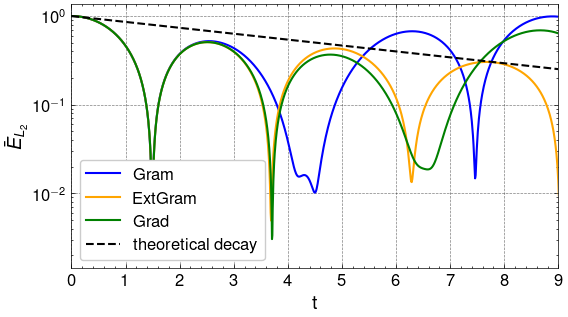

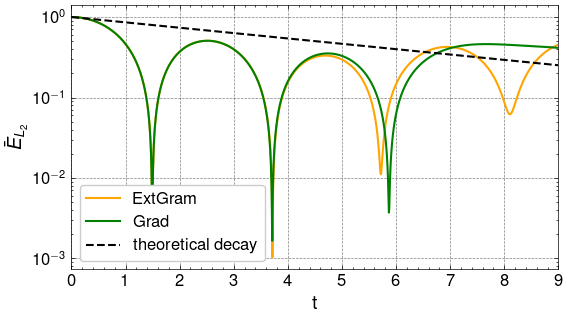

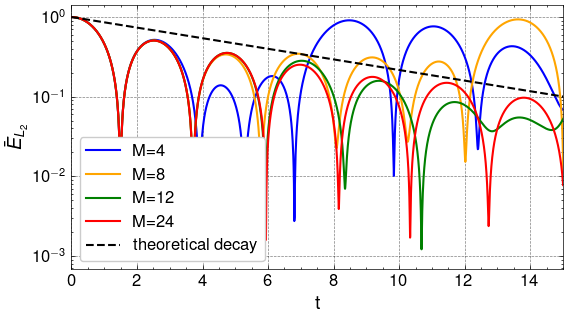

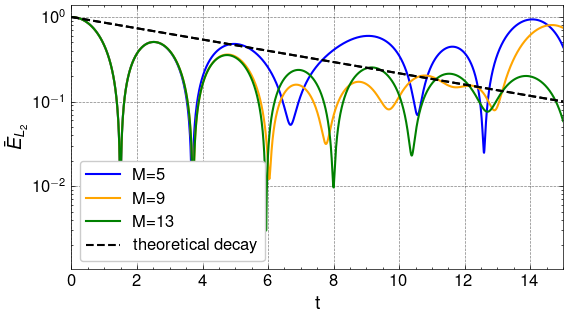

In [18]:
# Fixed M and different closures
Moments = [6, 7]
gamma = -0.1533

for M in Moments:
    fig, axs = plt.subplots(figsize=(WIDTH, .7*HEIGHT))
    for i, closure in enumerate(closures):
        if M == 7 and closure == 'Gram':
            continue #! to be fixed
        file = f"../out/VlasovPoisson/LandauDamping/energy_moments_solution_M{M}_closure{closure}_Kn{Kn}_T_end{T_end}_rho_0{rho_0}_v_0{v_0}_theta_0{theta_0}_epsilon{epsilon}_k{k}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
        data = pd.read_csv(file)

        axs.plot(data["time"], data["E_L2"] / data["E_L2"][0], color=colors[i], label=closure)
    axs.plot(data["time"], np.exp(gamma * data["time"]), 'k--', label="theoretical decay")
    axs.set_xlim(0, 9)
    axs.set_yscale("log")
    axs.set_xlabel("t")
    axs.set_ylabel("$\\bar{E}_{L_2}$")
    axs.legend(loc='lower left')
    fig.tight_layout()
    fig.savefig(f"../out/Figures/LandauDamping/LandauDamping_M{M}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
    fig.show()




# Fixed closure and different moments
Moments = [4, 8, 12, 24]
closure = 'ExtGram'

fig, axs = plt.subplots(figsize=(WIDTH, .7*HEIGHT))
for i, M in enumerate(Moments):
    file = f"../out/VlasovPoisson/LandauDamping/energy_moments_solution_M{M}_closure{closure}_Kn{Kn}_T_end{T_end}_rho_0{rho_0}_v_0{v_0}_theta_0{theta_0}_epsilon{epsilon}_k{k}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
    data = pd.read_csv(file)

    axs.plot(data["time"], data["E_L2"] / data["E_L2"][0], color=colors[i], label=f'M={M}')

axs.plot(data["time"], np.exp(gamma * data["time"]), 'k--', label="theoretical decay")
axs.set_yscale("log")
axs.set_xlim(0, 15)
axs.set_xlabel("t")
axs.set_ylabel("$\\bar{E}_{L_2}$")
axs.legend(loc='lower left')
fig.tight_layout()
fig.savefig(f"../out/Figures/LandauDamping/LandauDamping_Even_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig.show()

Moments = [5, 9, 13]#!, 25]
fig, axs = plt.subplots(figsize=(WIDTH, .7*HEIGHT))
for i, M in enumerate(Moments):
    file = f"../out/VlasovPoisson/LandauDamping/energy_moments_solution_M{M}_closure{closure}_Kn{Kn}_T_end{T_end}_rho_0{rho_0}_v_0{v_0}_theta_0{theta_0}_epsilon{epsilon}_k{k}_p{polydeg}_level{base_tree_level}_x_lower{x_lower}_x_upper{x_upper}.csv"
    data = pd.read_csv(file)

    axs.plot(data["time"], data["E_L2"] / data["E_L2"][0], color=colors[i], label=f'M={M}')

axs.plot(data["time"], np.exp(gamma * data["time"]), 'k--', label="theoretical decay")
axs.plot(data["time"], np.exp(gamma * data["time"]), 'k--')
axs.set_yscale("log")
axs.set_xlim(0, 15)
axs.set_xlabel("t")
axs.set_ylabel("$\\bar{E}_{L_2}$")
axs.legend(loc='lower left')
fig.tight_layout()
fig.savefig(f"../out/Figures/LandauDamping/LandauDamping_Odd_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig.show()

## Two-Stream Instability

In [19]:
def get_E_num(closure, T_end, M, k_, epsilon, polydeg, base_tree_level):
    file = f"../out/VlasovPoisson/TwoStreamInstability/energy_moments_closure{closure}_T{T_end}_M{M}_k{k_}_ϵ{epsilon}_p{polydeg}_level{base_tree_level}.csv"
    data = pd.read_csv(file)

    return data

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_42828/758586269.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


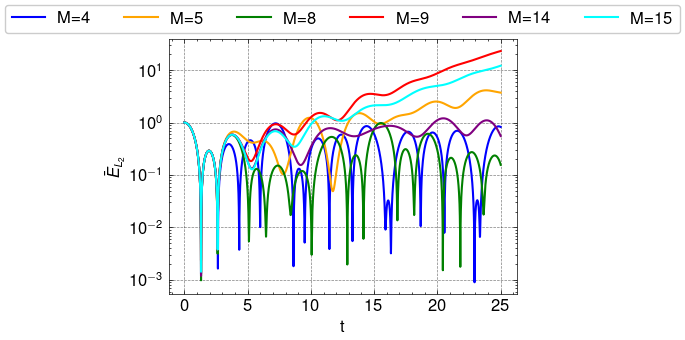

In [20]:
base_tree_level = 8
polydeg = 1
closure = "ExtGram"
Moments = [4, 5, 8, 9, 14, 15]

fig, axs = plt.subplots(figsize=(WIDTH, 0.75*HEIGHT))
for i, M in enumerate(Moments):
    data = get_E_num(closure, T_end, M, k, epsilon, polydeg, base_tree_level)
    axs.plot(data["time"], data["E_L2"] / data["E_L2"][0], color=colors[i], label=f'M={M}')
axs.set_yscale("log")
axs.set_xlabel("t", fontsize=12)
axs.set_ylabel("$\\bar{E}_{L_2}$", fontsize=12)
axs.legend(loc='center', ncol=6, bbox_to_anchor=(0.5, 1.08))
fig.savefig(f"../out/Figures/TwoStreamInstability/TwoStreamInstability_CompareMoments_{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf", bbox_inches='tight')
fig.tight_layout()
fig.show()

<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_42828/2855607525.py:11: SyntaxWarning: invalid escape sequence '\c'
  axs.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_42828/2855607525.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


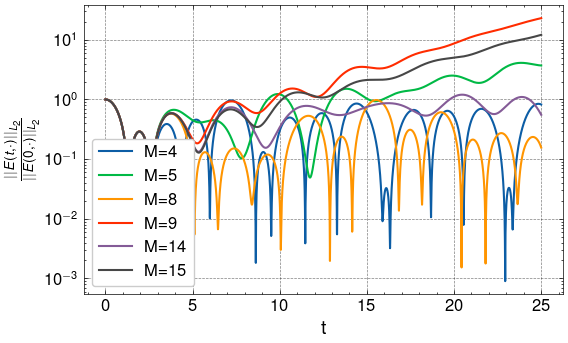

In [21]:
base_tree_level = 8
polydeg = 1
closure = "ExtGram"

fig, axs = plt.subplots(figsize=(WIDTH, 0.75*HEIGHT))
for i, M in enumerate(Moments):
    data = get_E_num(closure, T_end, M, k, epsilon, polydeg, base_tree_level)
    axs.plot(data["time"], data["E_L2"] / data["E_L2"][0], label=f'M={M}')
axs.set_yscale("log")
axs.set_xlabel("t")
axs.set_ylabel("$\\frac{||E(t,\cdot)||_{L_2}}{||E(0,\cdot)||_{L_2}}$")
# axs.set_title(closure)
axs.legend(loc='lower left')
# fig.savefig(f"../out/Figures/TwoStreamInstability/TwoStreamInstability_CompareMoments_{closure}_k{k}_epsilon{epsilon}_p{polydeg}.pdf")
fig.tight_layout()
fig.show()